# Lab 1: NumPy for Cat and Dog Faces

In this notebook, you will treat **cat and dog face images** as NumPy arrays and build a small hand-crafted feature matrix.

This version focuses on core NumPy image operations and keeps the workflow concrete:

- load an image into a NumPy array
- crop and flip with slicing
- normalize to `[0, 1]`
- convert RGB to grayscale
- compute summaries with `axis=`
- apply a small filter with a kernel and matrix multiplication
- flatten an image into one vector
- engineer features with `np.concatenate(...)` and `np.apply_along_axis(...)`
- stack features into a feature matrix for later machine learning work

**Dataset assumption**

Use the curated cat-and-dog-faces dataset extracted into:

`data/`

In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from lab_utils.visualization import (
    plot_feature_vector,
    show_image_gallery,
)

# Safe project root (works in scripts + notebooks)
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "data"

LABELS = ("cat", "dog")
LABEL_TO_INDEX = {"cat": 0, "dog": 1}

IMAGE_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

SEED = 1234

def label_from_path(path: Path) -> str:
    label = path.parent.name
    if label not in LABEL_TO_INDEX:
        raise ValueError(f"Unexpected label folder: {path}")
    return label


def load_preview_image(path: Path) -> np.ndarray:
    with Image.open(path) as image:
        return np.asarray(image.convert("RGB"))


def list_image_paths(label: str) -> list[Path]:
    label_dir = DATA_ROOT / label
    paths = []
    for pattern in IMAGE_EXTENSIONS:
        paths.extend(label_dir.glob(pattern))
    return sorted(paths)

def shuffled_paths(paths: list[Path], seed_offset: int = 0) -> list[Path]:
    rng = np.random.default_rng(SEED + seed_offset)
    indices = rng.permutation(len(paths))
    return [paths[int(idx)] for idx in indices]

def sample_paths(paths: list[Path], count: int, seed_offset: int) -> list[Path]:
    ordered = shuffled_paths(paths, seed_offset=seed_offset)
    return ordered[: min(count, len(ordered))]


def sample_per_class(paths: list[Path], n_per_class: int, seed_offset: int = 0) -> list[Path]:
    sampled = []
    for label_index, label in enumerate(LABELS):
        label_paths = [path for path in paths if label_from_path(path) == label]
        sampled.extend(sample_paths(label_paths, n_per_class, seed_offset + 50 * label_index))
    return sampled

def split_train_test(paths: list[Path], train_ratio: float = 0.7, seed_offset: int = 0):
    shuffled = shuffled_paths(paths, seed_offset)
    split_idx = int(len(shuffled) * train_ratio)
    return shuffled[:split_idx], shuffled[split_idx:]


# Check dataset exists
expected = [
    DATA_ROOT / "cat",
    DATA_ROOT / "dog",
]
if not all(path.exists() for path in expected):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_ROOT}. Expected 'cat' and 'dog' folders."
    )


# Load all paths
cat_paths = list_image_paths("cat")
dog_paths = list_image_paths("dog")
cat_dog_paths = cat_paths + dog_paths

# Split per class (7:3)
cat_train, cat_test = split_train_test(cat_paths, 0.7, seed_offset=0)
dog_train, dog_test = split_train_test(dog_paths, 0.7, seed_offset=100)

# Combine
train_paths = cat_train + dog_train
test_paths = cat_test + dog_test

print(f"Using dataset from: {DATA_ROOT}")
print(f"Found {len(cat_paths)} cat images")
print(f"Found {len(dog_paths)} dog images")

if len(cat_paths) == 0 or len(dog_paths) == 0:
    raise ValueError("No images found. Check folder paths or file extensions.")

Using dataset from: /workspaces/lab-1-numpy-hoangvi180206-1/data
Found 10 cat images
Found 10 dog images


### Visual Helper: Preview the Faces Dataset

Before starting the TODOs, look at a few cat and dog face images from the student-specific subset.


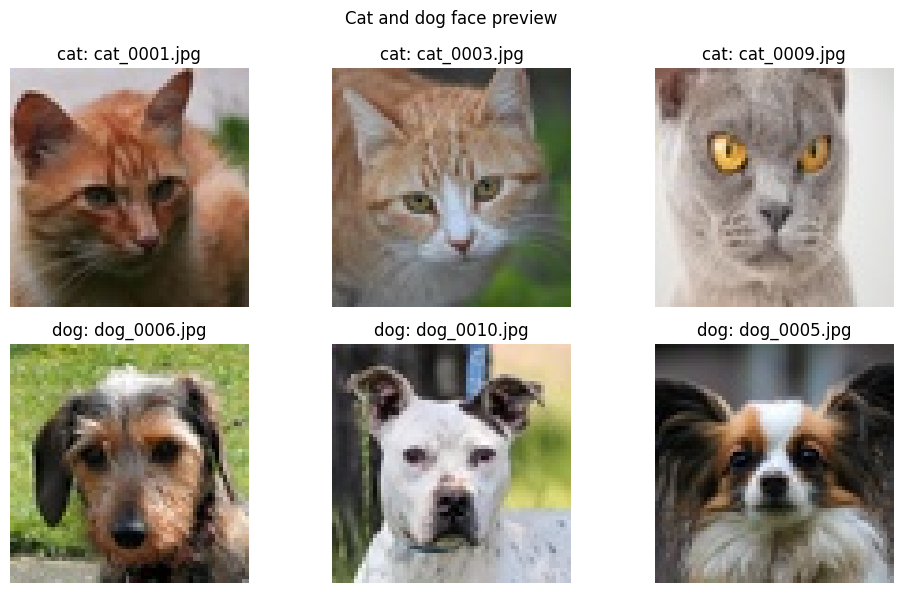

In [18]:
preview_paths = sample_per_class(cat_dog_paths, n_per_class=3, seed_offset=10)
preview_images = [load_preview_image(path) for path in preview_paths]
preview_titles = [f"{label_from_path(path)}: {path.name}" for path in preview_paths]
show_image_gallery(
    preview_images,
    titles=preview_titles,
    ncols=3,
    figsize=(10, 6),
    suptitle="Cat and dog face preview",
)
plt.show()


## Question 1: Load one image into a NumPy array

Write a function that:

- opens one file from disk
- converts it to RGB
- returns an `H x W x C` NumPy array

This is the starting point for every later NumPy operation in the lab.


shape: (64, 64, 3)
dtype: uint8
min/max: 0 255


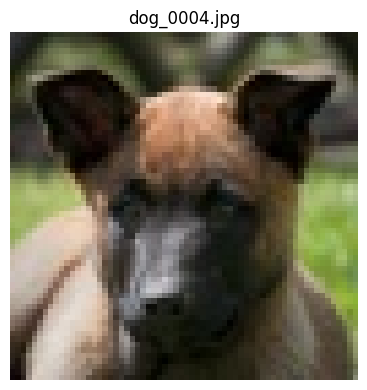

In [19]:
def load_image_np(path: Path) -> np.ndarray:
    with Image.open(path) as image:
        return np.asarray(image.convert("RGB"))

sample_path = dog_paths[3]
sample_image = load_image_np(sample_path)
print("shape:", sample_image.shape)
print("dtype:", sample_image.dtype)
print("min/max:", sample_image.min(), sample_image.max())
show_image_gallery([sample_image], titles=[sample_path.name], ncols=1, figsize=(4, 4))
plt.show()

## Question 2: Crop the image with slicing

Implement a centered square crop. Keep the crop size at `48 x 48` for the rest of the lab so the crop is visible and later operations stay consistent.


cropped shape: (48, 48, 3)


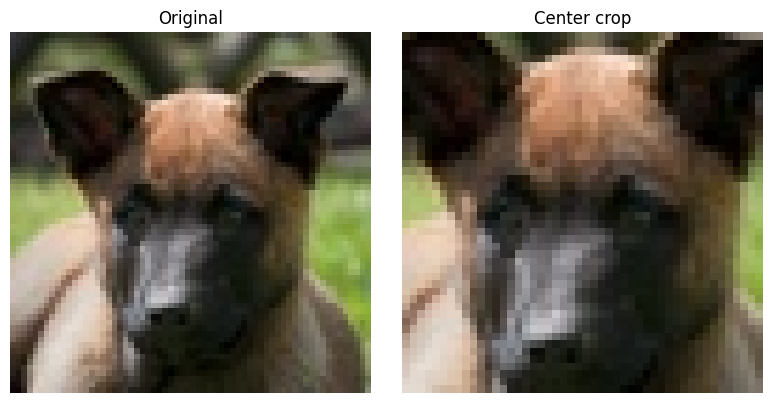

In [20]:
def center_crop(image: np.ndarray, crop_size: int = 48) -> np.ndarray:
    h, w, _ = image.shape
    start_y = (h - crop_size) // 2
    start_x = (w - crop_size) // 2
    return image[start_y:start_y + crop_size, start_x:start_x + crop_size]

cropped_image = center_crop(sample_image, crop_size=48)
print("cropped shape:", cropped_image.shape)
show_image_gallery(
    [sample_image, cropped_image],
    titles=["Original", "Center crop"],
    ncols=2,
    figsize=(8, 4),
)
plt.show()

## Question 3: Flip the crop horizontally

Mirror the cropped image from left to right using slicing only.


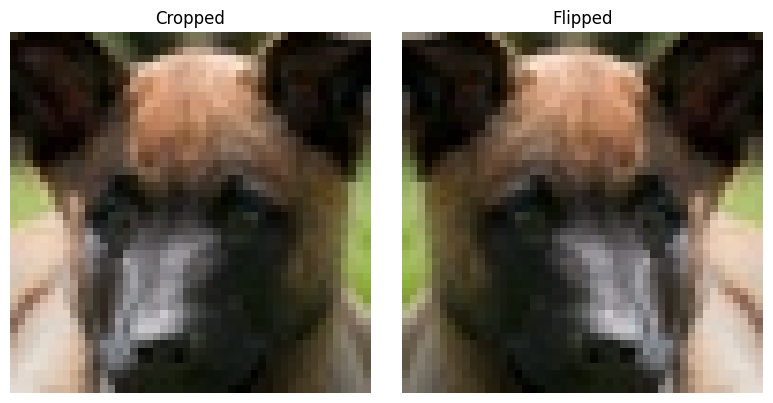

In [21]:
def flip_horizontal(image: np.ndarray) -> np.ndarray:
    # TODO: return a left-right flipped copy using slicing.
    return image[:, ::-1, :]


flipped_image = flip_horizontal(cropped_image)
show_image_gallery(
    [cropped_image, flipped_image],
    titles=["Cropped", "Flipped"],
    ncols=2,
    figsize=(8, 4),
)
plt.show()


## Question 4: Normalize pixels to `[0, 1]`

Convert the cropped RGB image from unsigned integers into `float32` values in the range `[0, 1]`.


Before: uint8 0 255
After : float32 0.0 1.0


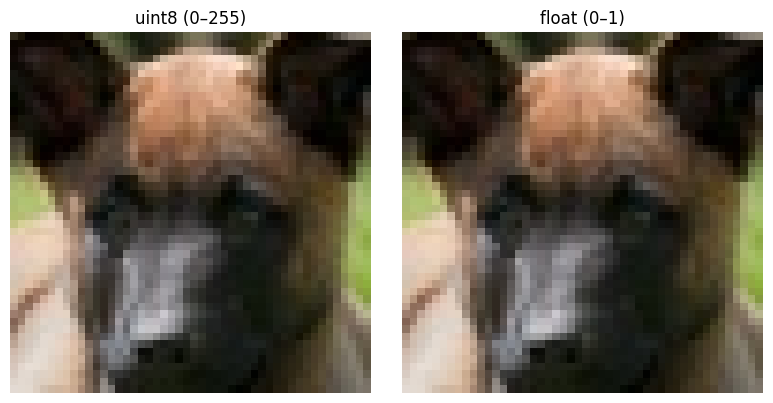

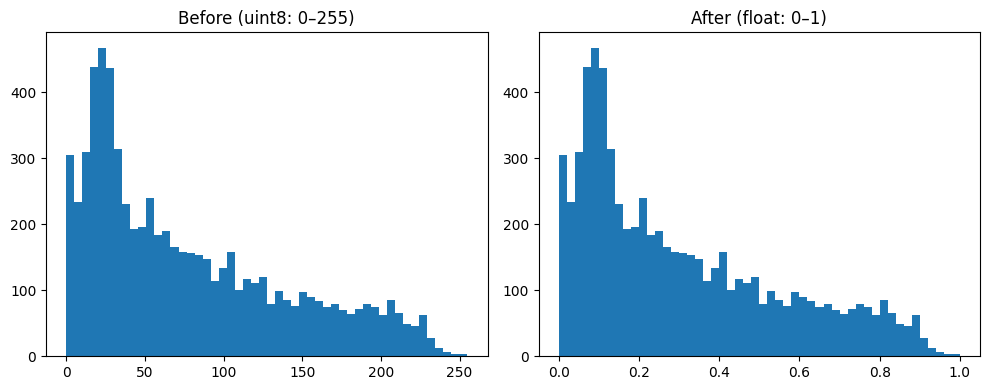

In [22]:
def normalize_01(image: np.ndarray) -> np.ndarray:
    # TODO: convert the image to float32 and divide by 255.
    return image.astype(np.float32) / 255.0

def show_histograms(uint8_img, float_img):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(uint8_img.ravel(), bins=50)
    plt.title("Before (uint8: 0–255)")

    plt.subplot(1, 2, 2)
    plt.hist(float_img.ravel(), bins=50)
    plt.title("After (float: 0–1)")

    plt.tight_layout()
    plt.show()

sample_float = normalize_01(cropped_image)

# 1. Side-by-side image (Both image will look the same)
show_image_gallery(
    [cropped_image, sample_float],
    titles=["uint8 (0–255)", "float (0–1)"],
    ncols=2,
    figsize=(8, 4),
)

# 2. Stats
print("Before:", cropped_image.dtype, cropped_image.min(), cropped_image.max())
print("After :", sample_float.dtype, sample_float.min(), sample_float.max())

# 3. Histogram
show_histograms(cropped_image, sample_float)

plt.show()


## Question 5: Convert RGB to grayscale

Turn the normalized RGB image into a single grayscale array using standard RGB weights 

$GREY = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$.


gray shape: (48, 48)
gray dtype: float64


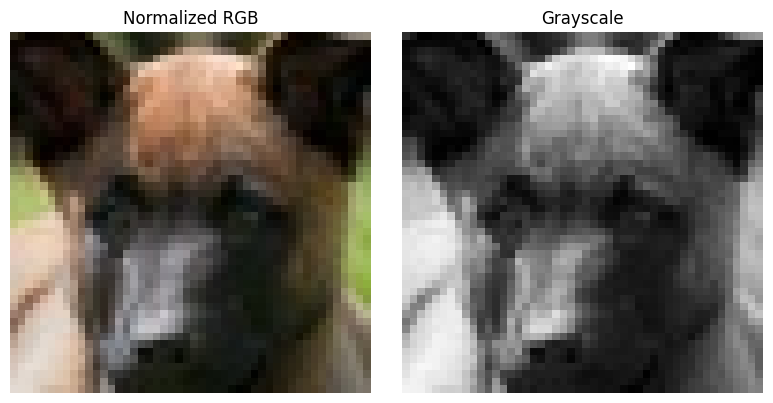

In [23]:
def rgb_to_gray(image_float: np.ndarray) -> np.ndarray:
    # TODO: convert normalized RGB values to one grayscale image.
    return np.dot(image_float[..., :3], [0.299, 0.587, 0.114])

sample_gray = rgb_to_gray(sample_float)
print("gray shape:", sample_gray.shape)
print("gray dtype:", sample_gray.dtype)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_float)
axes[0].set_title("Normalized RGB")
axes[0].axis("off")
axes[1].imshow(sample_gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")
fig.tight_layout()
plt.show()


## Question 6: Use `axis=` to summarize channels

Compute one mean value per color channel with `axis=(0, 1)`, then choose the brightest channel with `np.argmax(...)`.


channel means: [0.3527447  0.31142986 0.25127876]
brightest channel: red


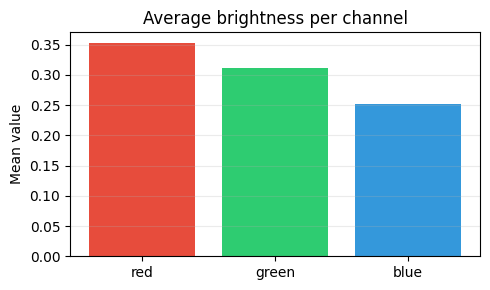

In [24]:
CHANNEL_NAMES = np.array(["red", "green", "blue"])


def channel_summary(image_float: np.ndarray) -> tuple[np.ndarray, int]:
    # TODO: compute per-channel means with axis=(0, 1) and return the brightest channel index.
    means = image_float.mean(axis=(0, 1))
    brightest = np.argmax(means)
    return means, brightest

sample_channel_means, sample_brightest = channel_summary(sample_float)
print("channel means:", sample_channel_means)
print("brightest channel:", CHANNEL_NAMES[sample_brightest])
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(CHANNEL_NAMES, sample_channel_means, color=["#E74C3C", "#2ECC71", "#3498DB"])
ax.set_title("Average brightness per channel")
ax.set_ylabel("Mean value")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


## Question 7: Apply a filter with a kernel and matrix multiplication

Implement a tiny 2D convolution on the grayscale image. At each location:

1. take a `3 x 3` patch
2. flatten the patch and kernel
3. multiply them with `@`

Use the Laplacian kernel from the setup cell.


filtered shape: (46, 46)


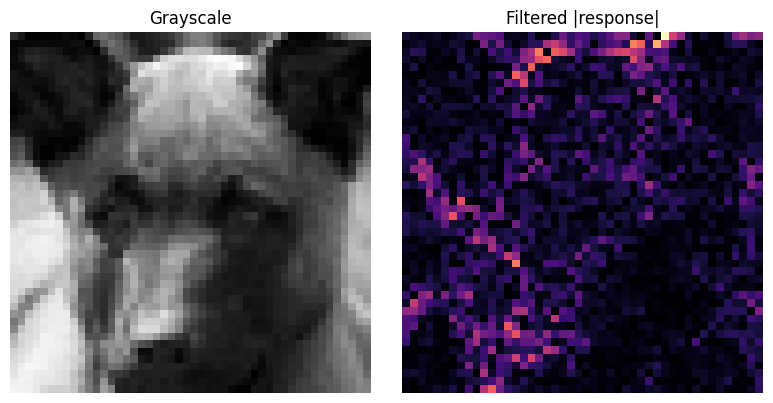

In [25]:
EDGE_KERNEL = np.array(
    [
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0],
    ],
    dtype=np.float32,
)


def convolve2d_matmul(image_gray: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    # TODO: slide the kernel over the image and use @ on flattened patches and the flattened kernel (or sum of elementwise products) to compute the response at each location.
    h, w = image_gray.shape
    kh, kw = kernel.shape
    out_h = h - kh + 1
    out_w = w - kw + 1
    output = np.zeros((out_h, out_w), dtype=np.float32)

    kernel_flat = kernel.flatten()

    for i in range(out_h):
        for j in range(out_w):
            patch = image_gray[i:i + kh, j:j + kw]
            output[i, j] = patch.flatten() @ kernel_flat

    return output


sample_filtered = convolve2d_matmul(sample_gray, EDGE_KERNEL)
print("filtered shape:", sample_filtered.shape)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")
axes[1].imshow(np.abs(sample_filtered), cmap="magma")
axes[1].set_title("Filtered |response|")
axes[1].axis("off")
fig.tight_layout()
plt.show()


## Question 8: Flatten one image into one vector

Take the grayscale crop and turn it into a one-dimensional vector.


original shape: (48, 48)
flat shape: (2304,)


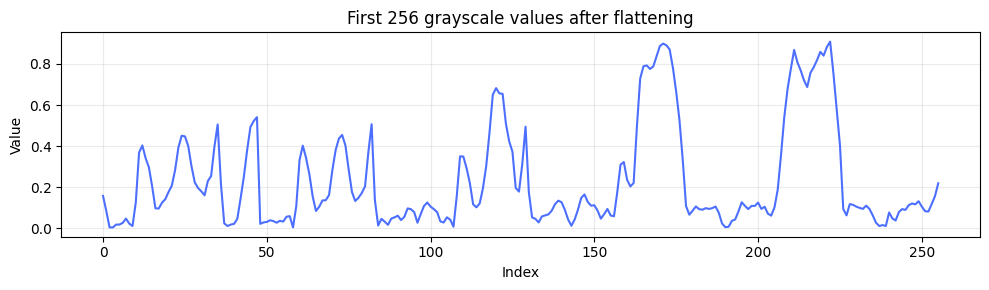

In [26]:
def flatten_image(image: np.ndarray) -> np.ndarray:
    # TODO: return a 1D vector version of the image.
    return image.reshape(-1)


sample_flat = flatten_image(sample_gray)
print("original shape:", sample_gray.shape)
print("flat shape:", sample_flat.shape)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(sample_flat[:256], color="#4C6FFF")
ax.set_title("First 256 grayscale values after flattening")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Question 9: Engineer a feature vector with `concatenate` and `apply`

Build one hand-crafted feature vector that combines:

- RGB means
- RGB standard deviations
- the brightest channel index
- the mean and standard deviation of the filtered response
- one summary from `np.apply_along_axis(...)`

Use `np.concatenate(...)` to join the pieces.


feature shape: (10,)


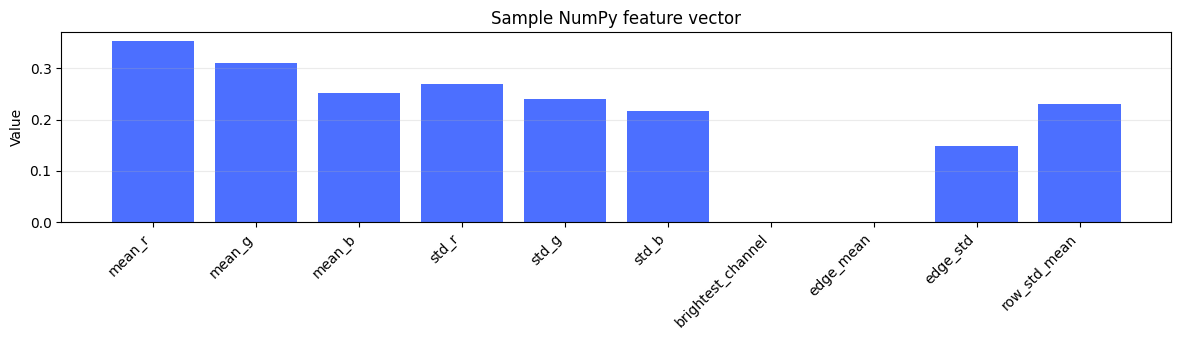

In [27]:
FEATURE_NAMES = [
    "mean_r",
    "mean_g",
    "mean_b",
    "std_r",
    "std_g",
    "std_b",
    "brightest_channel",
    "edge_mean",
    "edge_std",
    "row_std_mean",
]


def extract_features(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    cropped = center_crop(image, crop_size=48)
    image_float = normalize_01(cropped)
    gray = rgb_to_gray(image_float)
    channel_means, brightest_channel = channel_summary(image_float)
    channel_stds = image_float.std(axis=(0, 1)).astype(np.float32)
    filtered = convolve2d_matmul(gray, kernel)
    row_std_profile = np.apply_along_axis(np.std, 1, gray)

    # TODO: use np.concatenate to combine the feature pieces into one float32 vector.
    features = np.concatenate([
        channel_means,
        channel_stds,
        np.array([brightest_channel], dtype=np.float32),
        np.array([filtered.mean()], dtype=np.float32),
        np.array([filtered.std()], dtype=np.float32),
        np.array([row_std_profile.mean()], dtype=np.float32),
    ]).astype(np.float32)

    return features

sample_features = extract_features(sample_image, EDGE_KERNEL)
print("feature shape:", sample_features.shape)
fig, ax = plot_feature_vector(sample_features, FEATURE_NAMES, title="Sample NumPy feature vector")
plt.show()


## Question 10: Build and inspect a feature matrix

Apply your feature function to the small balanced train/test subsets from the face dataset.

Tasks:

1. build one feature matrix for the train images and one for the test images
2. return the matching integer labels
3. print the resulting shapes
4. compute an overall feature mean with `axis=0`
5. visualize the feature matrix and the average feature vector


X_train shape: (14, 10)
y_train shape: (14,)
X_test shape: (6, 10)
y_test shape: (6,)
train class counts: [7 7]
test class counts: [3 3]
overall train feature mean shape: (10,)


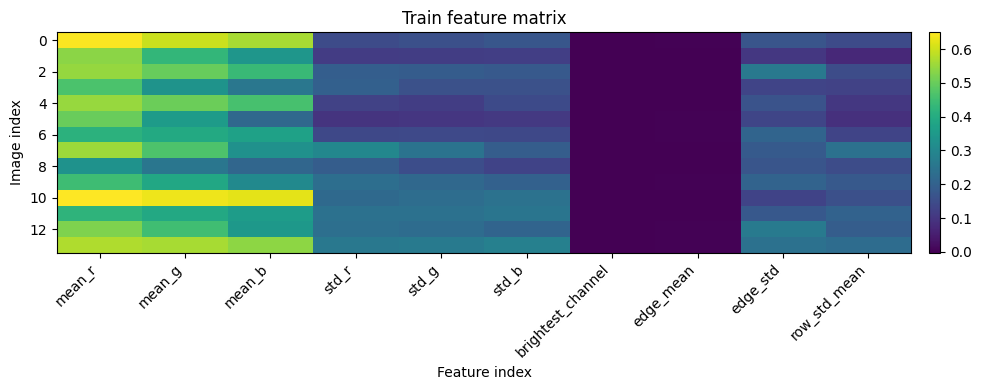

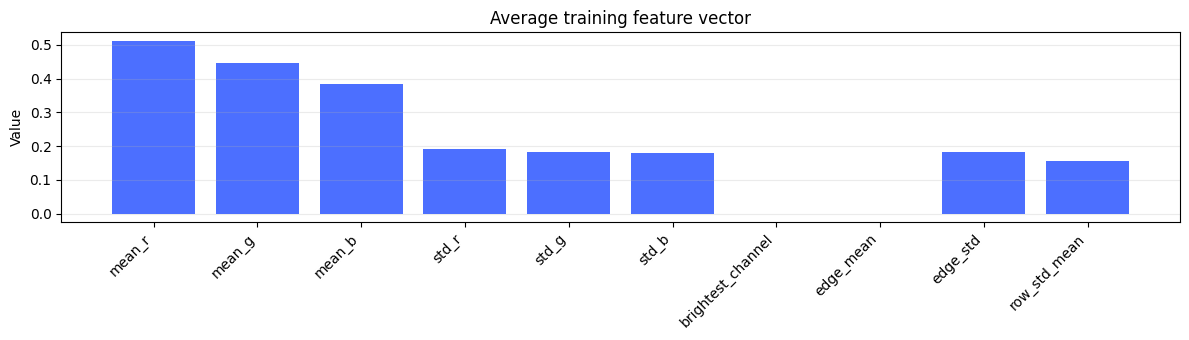

In [28]:
def build_feature_matrix(paths: list[Path], kernel: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # TODO: apply extract_features to every path and return X (features) and y (integer labels).
    X = []
    y = []

    for path in paths:
        image = load_image_np(path)
        features = extract_features(image, kernel)
        label = LABEL_TO_INDEX[label_from_path(path)]

        X.append(features)
        y.append(label)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


X_train, y_train = build_feature_matrix(train_paths, EDGE_KERNEL)
X_test, y_test = build_feature_matrix(test_paths, EDGE_KERNEL)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("train class counts:", np.bincount(y_train, minlength=2))
print("test class counts:", np.bincount(y_test, minlength=2))

train_feature_mean = X_train.mean(axis=0)
print("overall train feature mean shape:", train_feature_mean.shape)

fig, ax = plt.subplots(figsize=(10, 4))
image = ax.imshow(X_train, aspect="auto", cmap="viridis")
ax.set_title("Train feature matrix")
ax.set_xlabel("Feature index")
ax.set_ylabel("Image index")
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right")
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02)
fig.tight_layout()
plt.show()

fig, ax = plot_feature_vector(train_feature_mean, FEATURE_NAMES, title="Average training feature vector")
plt.show()


## Reflection

Answer these short questions in your own words:

1. Why is it useful to keep the crop size fixed before feature extraction?
2. What does `axis=(0, 1)` mean when you compute channel means on an image?
3. What information does the small edge filter capture that plain RGB means miss?
4. Why does flattening help some operations but also lose spatial structure?


1.
Because if images have different sizes then the features will be different too, so model will get confused. So we make same size to make everything consistent.

2.
axis=(0,1) means we take average over height and width, so we only keep one value for each channel (R, G, B).

3.
RGB mean only shows general color, but edge filter can see edges and changes, like shape or lines in the image.

4.
Flatten makes image into one long vector so it is easier to use, but it loses where the pixels are, so no position information anymore.